In [1]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [2]:
train_datagen= ImageDataGenerator(zoom_range=0.2,rotation_range=0.2,rescale=1/255)

In [3]:
test_datagen= ImageDataGenerator(rescale=1/255)

In [4]:
train_dataset= train_datagen.flow_from_directory(r"C:\Users\czone\Downloads\archive (1)\train",class_mode="categorical",target_size=(150,150),batch_size=16)

Found 28709 images belonging to 7 classes.


In [5]:
test_dataset= test_datagen.flow_from_directory(r"C:\Users\czone\Downloads\archive (1)\test",class_mode="categorical",target_size=(150,150),batch_size=16)

Found 7178 images belonging to 7 classes.


In [6]:
import tensorflow as tf

In [7]:
from tensorflow.keras.layers import Dense,Conv2D,MaxPool2D,Flatten,Dropout
from tensorflow.keras.models import Sequential

In [8]:
cnn=Sequential()

In [9]:
cnn.add(Conv2D(input_shape=(150,150,3),filters=32,kernel_size=3,activation="relu"))

C:\Users\czone\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
cnn.add(Conv2D(filters=80,kernel_size=3,activation="relu"))

In [11]:
from tensorflow.keras.callbacks import EarlyStopping
early=EarlyStopping(patience=5)

In [12]:
cnn.add(Dropout(0.5))

In [13]:
cnn.add(MaxPool2D(pool_size=2,strides=2))

In [14]:
cnn.add(Flatten())

In [15]:
cnn.add(Dense(units=64,activation="relu"))

In [16]:
cnn.add(Dense(units=7,activation="softmax"))

In [17]:
cnn.compile(optimizer="adam",loss="categorical_crossentropy",metrics=["accuracy"])

In [18]:
q=cnn.fit(train_dataset,validation_data=test_dataset,epochs=10)

Epoch 1/10
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 1690s 940ms/step - accuracy: 0.3133 - loss: 1.8108 - val_accuracy: 0.3562 - val_loss: 1.6508
Epoch 2/10
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 1597s 890ms/step - accuracy: 0.3580 - loss: 1.6301 - val_accuracy: 0.3982 - val_loss: 1.5858
Epoch 3/10
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 1524s 849ms/step - accuracy: 0.3926 - loss: 1.5546 - val_accuracy: 0.4166 - val_loss: 1.5264
Epoch 4/10
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 1525s 849ms/step - accuracy: 0.4174 - loss: 1.4948 - val_accuracy: 0.4405 - val_loss: 1.4700
Epoch 5/10
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 1615s 900ms/step - accuracy: 0.4460 - loss: 1.4350 - val_accuracy: 0.4485 - val_loss: 1.4635
Epoch 6/10
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 1705s 950ms/step - accuracy: 0.4663 - loss: 1.3882 - val_accuracy: 0.4539 - val_loss: 1.4317
Epoch 7/10
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 1703s 949ms/step - accuracy: 0.4813 - loss: 1.3562 - val_accuracy: 0.4319 - val_loss: 1.4661
Epoch 8/10
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 1612s 898ms/s

In [19]:
t_l=q.history["loss"]
v_l=q.history["val_loss"]

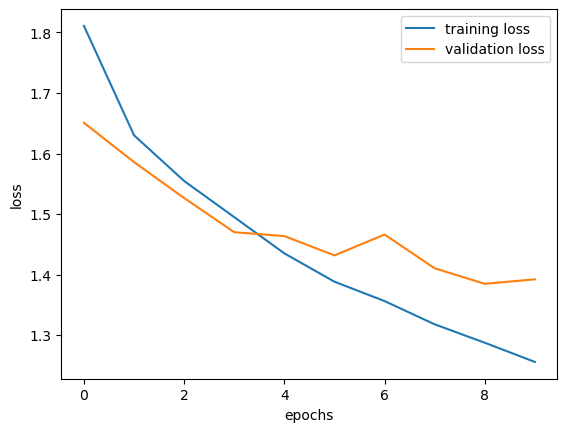

In [20]:
import matplotlib.pyplot as plt
plt.plot(t_l,label="training loss")
plt.plot(v_l,label="validation loss")
plt.xlabel("epochs")
plt.ylabel("loss")
plt.legend()
plt.show()

In [21]:
import cv2
cascade=cv2.CascadeClassifier(r"C:\Users\czone\Downloads\archive (1)\haarcascade_frontalface_default.xml")
import numpy as np

In [22]:
cap=cv2.VideoCapture(0)
while cap.isOpened():
    b,frame=cap.read()
    if not b:
        break
    #face detection
    faces=cascade.detectMultiScale(frame)
    for x,y,w,h in faces:
      face=frame[y:y+h,x:x+w]

    #resize image
      face=cv2.resize(face,(150,150))
      face=face/255
      face=np.expand_dims(face,axis=0)
    #prediction
      preds = cnn.predict(face)
      class_id = np.argmax(preds)
      if class_id==0:
        cv2.rectangle(frame,(x,y),(x+w,y+h),(0,0,0),3)
        cv2.putText(frame,"Angry",(x,y),cv2.FONT_HERSHEY_COMPLEX,0.8,(0,0,255),2)
      elif class_id==1:
          cv2.rectangle(frame,(x,y),(x+w,y+h),(0,255,0),3)
          cv2.putText(frame,"Disgusted",(x,y),cv2.FONT_HERSHEY_COMPLEX,0.8,(0,128,0),2)
      elif class_id==2:
          cv2.rectangle(frame,(x,y),(x+w,y+h),(0,255,0),3)
          cv2.putText(frame,"Fearful",(x,y),cv2.FONT_HERSHEY_COMPLEX,0.8,(128,0,128),2)
      elif class_id==3:
          cv2.rectangle(frame,(x,y),(x+w,y+h),(0,255,0),3)
          cv2.putText(frame,"Happy",(x,y),cv2.FONT_HERSHEY_COMPLEX,0.8,(0,255,0),2)
      elif class_id==4:
          cv2.rectangle(frame,(x,y),(x+w,y+h),(0,255,0),3)
          cv2.putText(frame,"Sad",(x,y),cv2.FONT_HERSHEY_COMPLEX,0.8,(255,0,0),2)
      elif class_id==5:
          cv2.rectangle(frame,(x,y),(x+w,y+h),(0,255,0),3)
          cv2.putText(frame,"Surprised",(x,y),cv2.FONT_HERSHEY_COMPLEX,0.8,(0,255,255),2)
      else:
        cv2.rectangle(frame,(x,y),(x+w,y+h),(255,0,0),3)
        cv2.putText(frame,"Neutral",(x,y),cv2.FONT_HERSHEY_COMPLEX,0.8,(200,200,200),2)
    cv2.imshow("frame",frame)
    if cv2.waitKey(1)==97:
        break
cap.release()
cv2.destroyAllWindows()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━